In [8]:
import matplotlib.pyplot as plt
import numpy as np
from ham import *

print("Hamlib version:", hamlibversion())

Hamlib version: 0.1.4


In [16]:
calset_raw = load_calset("testdata/calibrated/calset_50K_50M.cal")
calibration_set = calibrate_set( calset_raw )

freqs, ref_s11 = load_s1p("testdata/calibrated/c_50K_50M.s1p")
freqs, signal_s11 = load_s1p("testdata/uncalibrated/c_50K_50M.s1p")


s11_calibrated = []

for i, freq in enumerate(freqs):
    cal = calibration_set.get(freq)
    
    if cal is None:
        raise ValueError(f"No calibration data available for frequency {freq} Hz")
    
    cal_s11 = apply_calibration(signal_s11[i], cal["Ed"], cal["Es"], cal["Er"])
    s11_calibrated.append(cal_s11)

s11_calibrated = np.array(s11_calibrated)

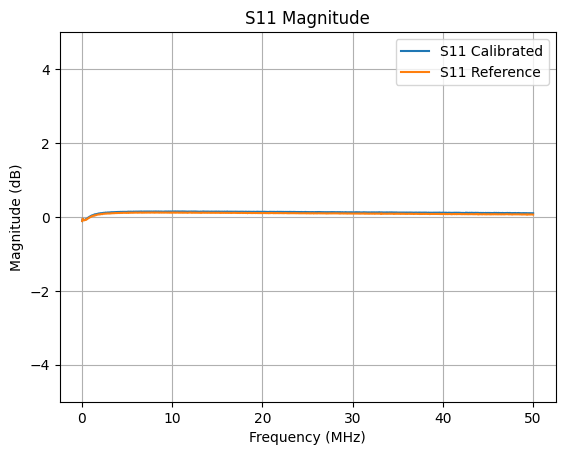

In [18]:
plt.plot(freqs / 1e6, 20 * np.log10(np.abs(s11_calibrated)), label="S11 Calibrated")
plt.plot(freqs / 1e6, 20 * np.log10(np.abs(ref_s11)), label="S11 Reference")
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Magnitude (dB)")
plt.title("S11 Magnitude")
plt.ylim(-5, 5)
plt.legend()
plt.grid()
plt.show()

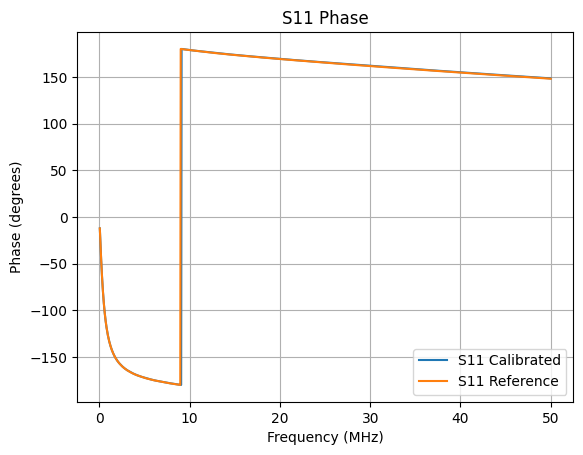

In [19]:
plt.plot(freqs / 1e6, np.angle(s11_calibrated, deg=True), label="S11 Calibrated")
plt.plot(freqs / 1e6, np.angle(ref_s11, deg=True), label="S11 Reference")
plt.xlabel("Frequency (MHz)")   
plt.ylabel("Phase (degrees)")
plt.title("S11 Phase")
plt.legend()
plt.grid()
plt.show()

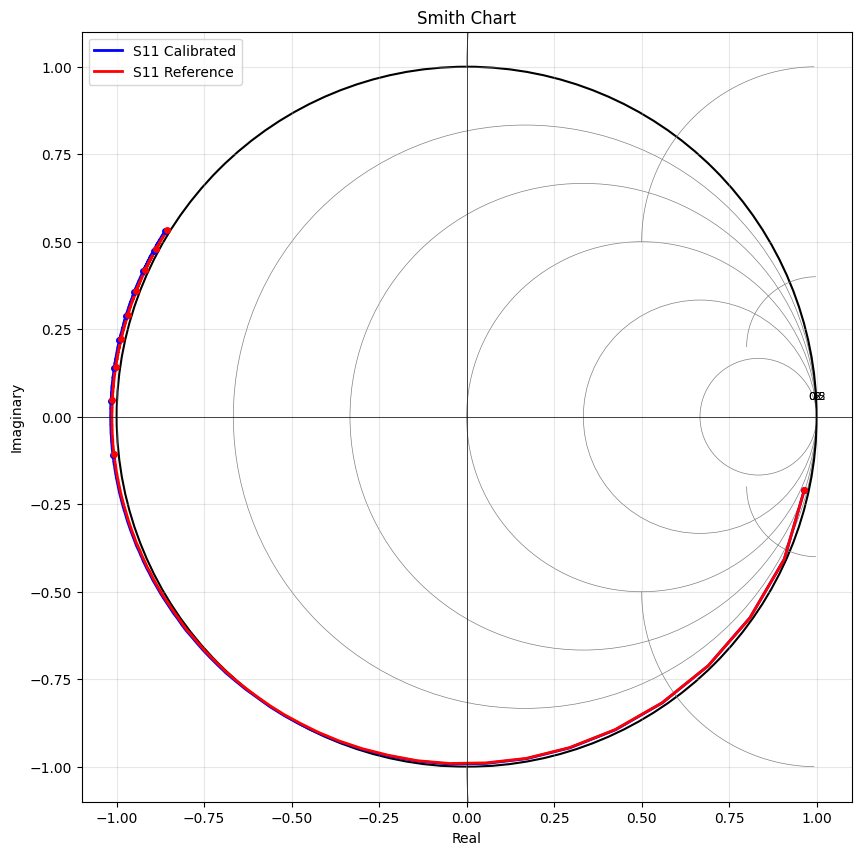

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

# Draw Smith chart circles (constant resistance)
for r in [0, 0.2, 0.5, 1, 2, 5]:
    radius = 1 / (r + 1)
    center_x = r / (r + 1)
    circle = Circle((center_x, 0), radius, fill=False, color='gray', linewidth=0.5)
    ax.add_patch(circle)
    if r > 0:
        ax.text(center_x + radius, 0.05, f'{r}', fontsize=8, ha='center')

# Draw constant reactance arcs (simplified)
for x in [0.2, 0.5, 1, 2, 5, -0.2, -0.5, -1, -2, -5]:
    t = np.linspace(0, np.pi if x > 0 else -np.pi, 100)
    radius = 1 / abs(x)
    center_y = 1 / x
    arc_x = 1 + radius * np.cos(t)
    arc_y = center_y + radius * np.sin(t)
    mask = (arc_x >= -1) & (arc_x <= 1)
    ax.plot(arc_x[mask], arc_y[mask], color='gray', linewidth=0.5)

# Draw outer circle
outer_circle = Circle((0, 0), 1, fill=False, color='black', linewidth=1.5)
ax.add_patch(outer_circle)

# Plot the S11 data
ax.plot(s11_calibrated.real, s11_calibrated.imag, 'b-', linewidth=2, label='S11 Calibrated')
ax.plot(ref_s11.real, ref_s11.imag, 'r-', linewidth=2, label='S11 Reference')

# Add frequency markers
marker_indices = np.linspace(0, len(freqs)-1, 10, dtype=int)
for idx in marker_indices:
    ax.plot(s11_calibrated[idx].real, s11_calibrated[idx].imag, 'bo', markersize=4)
    ax.plot(ref_s11[idx].real, ref_s11[idx].imag, 'ro', markersize=4)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('Smith Chart')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()